In [1]:
import json
import torch
import numpy as np
from tqdm.auto import tqdm
from torch.utils.data import Dataset
import logging

logger = logging.getLogger(__name__)

class RetrievalHotPotQA(Dataset):
    def __init__(self,
                 path,
                 tokenizer,
                 length = -1,
                 min_context_len = -1,
                 max_context_len = 1e7,
                 seed = 52,
                 **kwargs
        ):
        super().__init__()
        split = kwargs.pop('split')
        if split not in ['train', 'eval', 'all',  'fullwiki_eval']:
            #'all' includes 'train' and 'eval' but not fullwiki_eval
            raise ValueError(f'unknown split for hotpotqa dataset: {split}')
        self.split = split
        logger.info(f"{type(self)} received unknown kwargs: {kwargs}")
        self.length = length
        self.min_context_len = min_context_len
        self.max_context_len = max_context_len
        self.tokenizer = tokenizer

        np.random.seed(seed)
        self._load_data(path)

    def name(self):
        return 'hotpotqa'

    def _load_data(self, path):
        self.tasks = []

        raw_tasks = []
        if self.split in ['eval', 'all']:
            with open(path + '/hotpot_dev_distractor_v1.json', 'r') as json_file:
                raw_tasks.extend(map(lambda x: (x, 'eval'), json.load(json_file)))

        if self.split in ['train', 'all']:
            with open(path + '/hotpot_train_v1.1.json', 'r') as json_file:
                raw_tasks.extend(map(lambda x: (x, 'train'), json.load(json_file)))

        if self.split == 'fullwiki_eval':
            with open(path + '/hotpot_dev_fullwiki_v1.json', 'r') as json_file:
                raw_tasks.extend(map(lambda x: (x, 'fullwiki_eval'), json.load(json_file)))


        for task, partition in tqdm(raw_tasks, "HotPotQA load"):
            context = " ".join(title + " ".join(sentences) for title, sentences in task["context"])
            context = task['question'] + context
            context_len = len(self.tokenizer(context)["input_ids"])

            if self.min_context_len <= context_len <= self.max_context_len:
                self.tasks.append(self._adapt_raw_sample(task))

        self.tasks = np.random.permutation(self.tasks)
        if self.length >= 0:
            self.tasks = self.tasks[:self.length]


    def _adapt_raw_sample(self, sample):
        """Adapt sample to unified format expected by the model"""
        return sample


    def __len__(self):
        return len(self.tasks)

    def __getitem__(self, idx):
        return self.tasks[idx]

In [3]:
import numpy as np
from collections import namedtuple
from typing import Tuple, Dict, List, Any, Union
import torch.utils
from nltk.probability import gt_demo
from torch.utils.data import Dataset

import sys
import os
sys.path.append(os.path.abspath('/trinity/home/a.anokhin/stage_2/pqn/multi-step-retrieval-rl-pqn-29_05'))

# from rl.jax_text_env import TextEnv, TextMemory, TextMemoryItem
from rl.text_env import TextEnv, TextMemory, TextMemoryItem
from transformers import PreTrainedTokenizer, PreTrainedTokenizerFast

    
class SimpleEnvAdapter(Dataset):
    """
    Simple adapter that adapts datasets Babilong, HotPotQA and MUSIQUE for QAREtreievalEnv.
    This adapter doesn't tokenize or embeds text chunks.

    You can create different adapter that for example tokenize every text in a sample or
    build faiss index over text chunks.
    """

    def __init__(self, dataset, min_chunks=6): # Добавили параметр min_chunks
        super().__init__()
        
        original_dataset = dataset
        self.dataset_name = original_dataset.name()
        
        # --- НАЧАЛО ИЗМЕНЕНИЙ ---
        
        print(f"Фильтрация датасета '{self.dataset_name}'. Исходный размер: {len(original_dataset)}.")
        print(f"Удаляются сэмплы, где количество чанков (контекстных параграфов) меньше {min_chunks}.")
        
        filtered_dataset = []
        for sample in original_dataset:
            # Логика определения количества чанков должна соответствовать тому,
            # как они создаются в __getitem__. Для hotpotqa это len(sample['context']).
            num_chunks = 0
            if self.dataset_name == 'hotpotqa':
                num_chunks = len(sample.get('context', []))
            # elif self.dataset_name == 'musique':
            #     num_chunks = len(sample.get('paragraphs', []))
            # elif self.dataset_name == 'babilong':
            #     num_chunks = len(sample.get('chunks', []))
            
            if num_chunks >= min_chunks:
                filtered_dataset.append(sample)

        self.dataset = filtered_dataset
        
        print(f"Фильтрация завершена. Новый размер датасета: {len(self.dataset)}.")

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        sample = self.dataset[index]
        question = sample["question"]
        if question.endswith("?"):
            question = question[:-1]

        sf_idx = []
        chunks_texts = []
        if self.dataset_name == 'hotpotqa':
            sp_title_set = set()
            sample_id = sample['_id']
            for sup in sample['supporting_facts']:
                sp_title_set.add(sup[0])

            for idx, (title, sentences) in enumerate(sample['context']):
                if title in sp_title_set:
                    sf_idx.append(idx)
                chunk = title + " " + " ".join(sentences)
                chunks_texts.append(chunk)

        elif self.dataset_name == 'musique':
            sample_id = sample['id']
            for i, para in enumerate(sample['paragraphs']):
                # if para['is_supporting']:
                #     sf_idx.append(i)
                chunk = para['title'] + '. ' + para['paragraph_text']
                chunks_texts.append(chunk)

            # label order
            for item_json in sample['question_decomposition']:
                sf_idx.append(item_json['paragraph_support_idx'])

        elif self.dataset_name == 'babilong':
            sample_id = index
            for i, sent in enumerate(sample['chunks']):
                chunks_texts.append(sent)

            for i in sample['references_idx']:
                sf_idx.append(i)

        return {
            'id': sample_id,
            'question': question,
            'answer': sample["answer"],
            'chunks_texts': chunks_texts,
            'sf_idx': sf_idx,
        }


class GroundTruthReward:
    def __init__(self, only_at_max_step=False):
        super().__init__()
        self.only_at_max_step = only_at_max_step

    def reward(self, env, action):
        if self.only_at_max_step and (env.num_steps < env.max_steps):
            return 0.

        is_retrieved = []
        for r in env.references:
            is_retrieved.append(r in env.text_state)

        all_retrieved = all(is_retrieved)
        return float(all_retrieved)


class PositionalGTReward(GroundTruthReward):
    """
    This version takes into account position of the support facts.
    In babi tasks several events could have completely identical text descriptions,
    but only one of them can be considered a support fact/reference fact.

    I.E. Merry could visit the same location several times.
    But only the last event allows us to tell where she is at the end of the story.

    This reward takes into account temporal information that allows to distinguish
    true support facts, from similar events.
    """
    def reward(self, env, action):
        if self.only_at_max_step and (env.num_steps < env.max_steps):
            return 0.

        pred_sf = set(map(int, env.memory.item_ids))
        gt_sf = set(env.references_idx)
        return 1.0 if gt_sf.issubset(pred_sf) else 0.0

class QARetrievalEnv(TextEnv):  # Наследуемся напрямую от TextEnv
    def __init__(self,
                 dataset: SimpleEnvAdapter, # Явно указываем тип для ясности
                 max_steps = 4,
                 index_type="random", # "absolute", "relative" - используется TextEnv?
                 reward_model=GroundTruthReward()):
        
        super().__init__() # Вызов конструктора TextEnv

        self.dataset = dataset # Это будет SimpleEnvAdapter
        self.max_steps = max_steps
        self.index_type = index_type # Если TextEnv его использует, иначе можно убрать
        self.reward_model = reward_model

        # Атрибуты, которые ранее устанавливались в BabilongEnv или его _init_from_sample
        # и используются в методах, которые мы скопируем или уже имеем
        self.references: List[str] = []
        self.question: str = ""
        self.answer: Any = None # Тип ответа может быть разным
        self.sentences: np.ndarray = np.array([]) # Массив текстов "чанков"
        self.facts_idx: List[int] = [] # Индексы "фактов" (в контексте Adapted это sf_idx)
        self.references_idx: List[int] = [] # Индексы релевантных чанков

        self.num_steps: int = 0
        self.text_state: List[str] = [] # Хранит тексты выбранных чанков

        # Атрибуты, которые могли быть в BabilongEnv и используются reward_model или др. логикой
        # self.refs_found = [] # Если используется где-то еще, кроме как локально в BabilongEnv.reset

    def _init_from_sample(self, sample: Dict[str, Any]):
        # 'sample' здесь приходит от SimpleEnvAdapter
        # Формат sample: {'id'(опционально), 'question', 'answer', 'chunks_texts', 'sf_idx'}
        
        self.question = sample['question']
        self.answer = sample['answer']
        self.sentences = np.asarray(sample['chunks_texts']) # Это будут наши "чанки"
        
        # 'sf_idx' из SimpleEnvAdapter - это индексы релевантных чанков в 'chunks_texts'
        # Это соответствует 'references_idx'
        self.references_idx = list(map(int, sample['sf_idx'])) # Убедимся, что это int
        
        # 'references' - это тексты релевантных чанков
        self.references = [self.sentences[i] for i in self.references_idx if 0 <= i < len(self.sentences)]
        
        # 'facts_idx' - для совместимости и если какая-то логика на них полагается.
        # В данном контексте "факты" это и есть поддерживающие чанки.
        self.facts_idx = list(self.references_idx) 
        
        # Опционально: отладочный вывод
        # print(f"QARetrievalEnv._init_from_sample: sample keys: {sample.keys()}")
        # print(f"  question: {self.question}")
        # print(f"  sentences len: {len(self.sentences)}")
        # print(f"  references_idx (from sf_idx): {self.references_idx}")
        # print(f"  facts_idx (set to sf_idx): {self.facts_idx}")

    def reset(self, new_sample: Dict[str, Any] = None) -> TextMemory:
        if new_sample is not None:
            self._init_from_sample(new_sample)
        elif self.dataset is not None:
            # Эта часть предполагает, что self.dataset (SimpleEnvAdapter)
            # поддерживает __len__ и __getitem__ для случайного выбора.
            # Если SimpleEnvAdapter предоставляет другой API (например, .sample()),
            # эту логику нужно будет адаптировать.
            try:
                N = len(self.dataset)
                if N == 0:
                    raise ValueError("Dataset is empty.")
                i = np.random.randint(N)
                sample_from_dataset = self.dataset[i]
                self._init_from_sample(sample_from_dataset)
            except (TypeError, NotImplementedError) as e:
                # Если __len__ или __getitem__ не реализованы, попробуем .sample()
                if hasattr(self.dataset, 'sample') and callable(getattr(self.dataset, 'sample')):
                    try:
                        sample_from_dataset = self.dataset.sample()
                        self._init_from_sample(sample_from_dataset)
                    except Exception as sample_e:
                        raise RuntimeError(f"Failed to get sample using .sample() from dataset: {sample_e}") from sample_e
                else:
                    raise RuntimeError(
                        "Dataset adapter does not support len()/getitem[] for sampling, "
                        "nor does it have a .sample() method. "
                        "Please provide new_sample directly to reset() or adapt the adapter."
                    ) from e
        else:
            # Если нет ни new_sample, ни dataset, это ошибка конфигурации
            raise ValueError("Cannot reset environment: no new_sample provided and no dataset configured.")


        self.num_steps = 0
        self.text_state = [] # Сбрасываем историю выбранных текстов
        self.refs_found = [] # Если этот атрибут был и использовался, его тоже сбрасываем

        # _reset из TextEnv должен инициализировать TextMemory на основе question и sentences
        # TextEnv._reset(self, query: str, chunks: Union[List[str], np.ndarray]) -> TextMemory
        return super()._reset(self.question, self.sentences)
   
    def step(self, action: int): # -> Tuple[TextMemory, TextMemoryItem, float, bool]
                                 # TextMemoryItem определен в rl.text_env
        self.num_steps += 1
        done = self.num_steps >= self.max_steps
        
        # _step из TextEnv должен обновить память и вернуть выбранный элемент
        # TextEnv._step(self, action_idx: int) -> Tuple[TextMemory, TextMemoryItem, bool]
        # где bool это text_done (например, если память переполнилась или все элементы выбраны)
        text_memory, text_item, text_done = super()._step(action)
        
        # Добавляем текст выбранного чанка в self.text_state для GroundTruthReward
        if 0 <= action < len(self.sentences):
            self.text_state.append(self.sentences[action])
        else:
            # Это не должно происходить, если action всегда валидный индекс
            # Можно добавить логгирование или обработку ошибки
            print(f"Warning: Action {action} is out of bounds for sentences (len: {len(self.sentences)})")


        r = self._reward(action)
        # Если достигнута цель (например, все референсы найдены), эпизод может завершиться досрочно
        if r > 1e-5: # Сравниваем с небольшим эпсилон, т.к. награда может быть float
            done = True
    
        return text_memory, text_item, r, done or text_done

    def _reward(self, action: int) -> float:
        # Используем self.reward_model, который был передан в конструкторе
        return self.reward_model.reward(self, action)

    @property
    def device(self):
        # Предполагаем, что TextEnv (родительский класс) управляет эмбеддером
        # и предоставляет доступ к его устройству.
        # Если TextEnv не имеет self.embedder, эту часть нужно адаптировать.
        if hasattr(self, 'embedder') and self.embedder is not None:
            return self.embedder.device
        # Заглушка или ошибка, если embedder не найден (зависит от реализации TextEnv)
        # print("Warning: embedder not found or not initialized in TextEnv for .device property.")
        return "cuda:0" # или None, или raise AttributeError

    def get_sample_len(self, tokenizer) -> int:
        """
        Return total length of all texts (question + chunks) in the current task,
        tokenized by the provided tokenizer.
        """
        if not self.question or self.sentences is None or len(self.sentences) == 0:
            # Это может случиться, если reset() не был вызван или не отработал корректно
            # print("Warning: get_sample_len called before environment was properly reset with data.")
            return 0
        
        total_len = len(tokenizer(self.question)['input_ids'])
        # Убедимся, что sentences - это список строк для токенизатора
        sentences_list = list(self.sentences)
        if sentences_list: # Проверка, что список не пустой
            # Некоторые токенизаторы могут возвращать список списков input_ids, если на вход список строк
            tokenized_chunks = tokenizer(sentences_list)['input_ids']
            total_len += sum(len(chunk_ids) for chunk_ids in tokenized_chunks)
        return total_len

    def copy(self):
        # Создаем копию этого же класса
        # self.dataset (SimpleEnvAdapter) и self.reward_model передаются по ссылке,
        # что обычно является ожидаемым поведением для таких объектов.
        # Если нужна глубокая копия этих объектов, ее нужно реализовать отдельно.
        return QARetrievalEnv(dataset=self.dataset,
                                  max_steps=self.max_steps,
                                  index_type=self.index_type,
                                  reward_model=self.reward_model)

In [29]:
from transformers import AutoTokenizer
seed = 42
split = 'train'
tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-base')
path = '/trinity/home/a.anokhin/rmt_other_datasets/data/dataloaders/data_sources/hotpotqa'

dataset = RetrievalHotPotQA(
    path=path, tokenizer=tokenizer, length=-1,
    min_context_len=0, max_context_len=1e7,
    type='any', anno_type='any', split=split, seed=seed
)

HotPotQA load:   0%|          | 0/90447 [00:00<?, ?it/s]

In [30]:
dataset[0]

{'supporting_facts': [['Same-sex marriage in the Sixth Circuit', 0],
  ['Same-sex marriage in Ohio', 1]],
 'level': 'medium',
 'question': 'Who was the widow affected by the Same-sex marriage decision ruled on by the Sixth Circuit from Ohio?',
 'context': [['Bourke v. Beshear',
   ['The lead cases on same-sex marriage in Kentucky are Bourke v. Beshear, and its companion case Love v. Beshear.',
    ' In "Bourke", a U.S. district court found that the Equal Protection Clause requires Kentucky to recognize valid same-sex marriages from other jurisdictions.',
    ' In "Love", the same court found that this same clause renders Kentucky\'s ban on same-sex marriage unconstitutional.',
    ' Both decisions were stayed and consolidated upon appeal to the Sixth Circuit Court of Appeals, which heard oral arguments in both cases on August 6, 2014.',
    " On November 6, the Sixth Circuit upheld Kentucky's ban on same-sex marriage."]],
  ['Same-sex marriage in Mississippi',
   ['Same-sex marriage is

In [31]:
dataset[0]['supporting_facts']

[['Same-sex marriage in the Sixth Circuit', 0],
 ['Same-sex marriage in Ohio', 1]]

In [32]:
dataset = SimpleEnvAdapter(dataset)

Фильтрация датасета 'hotpotqa'. Исходный размер: 90447.
Удаляются сэмплы, где количество чанков (контекстных параграфов) меньше 6.
Фильтрация завершена. Новый размер датасета: 89847.


In [6]:
count_chunks = []
for i in range(len(dataset)):
    tmp = len(dataset[i]['chunks_texts'])
    count_chunks.append(tmp)

min(count_chunks)

2

In [11]:
count_2 = 0
count_3 = 0
count_4 = 0
count_5 = 0

for i in count_chunks:
    if i == 2:
        count_2 += 1
    elif i == 3:
        count_3 += 1
    elif i == 4:
        count_4 += 1
    elif i == 5:
        count_5 += 1

# Для вывода результатов:
print(f"Количество 2: {count_2}")
print(f"Количество 3: {count_3}")
print(f"Количество 4: {count_4}")
print(f"Количество 5: {count_5}")

Количество 2: 262
Количество 3: 156
Количество 4: 94
Количество 5: 88


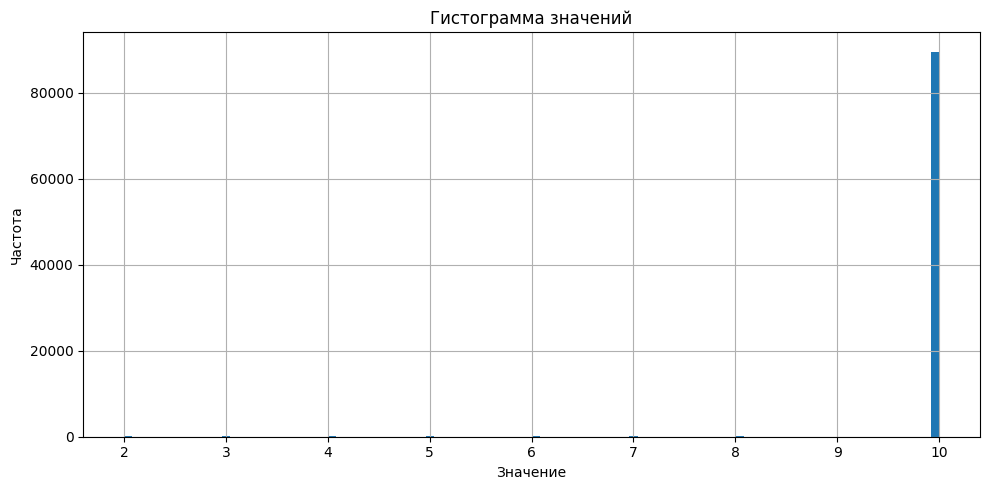

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(count_chunks, bins=100)
plt.title("Гистограмма значений")
plt.xlabel("Значение")
plt.ylabel("Частота")
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
count_sf = []
for i in range(len(dataset)):
    tmp = len(dataset[i]['sf_idx'])
    count_sf.append(tmp)
    if tmp == 12:
        print(i)

min(count_sf)

2

In [34]:
max(count_sf)

2

In [28]:
dataset[66474]

IndexError: list index out of range

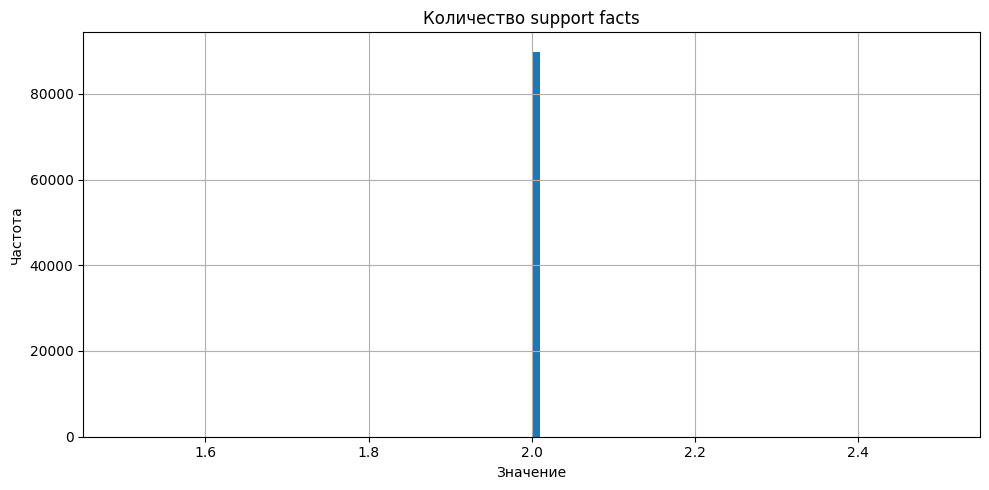

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(count_sf, bins=100)
plt.title("Количество support facts")
plt.xlabel("Значение")
plt.ylabel("Частота")
plt.grid(True)
plt.tight_layout()
plt.show()

In [44]:
len(dataset[2000]['chunks_texts'])

10

In [10]:
env = QARetrievalEnv(dataset)

In [36]:
print("\nResetting environment...")
obs_memory = env.reset() # TextMemory object

print(f"Environment reset. Question: '{env.question}'")
print(f"Available sentences (chunks): {len(env.sentences)}")
# print("Sentences:", env.sentences)
print(f"Target reference indices: {env.references_idx}")
print(f"Target reference texts: {env.references}")

done = False
total_reward = 0
for step_num in range(env.max_steps):
    if done:
        break
    action = np.random.randint(0, len(env.sentences)) # Случайное действие
    print(f"\nStep {step_num + 1}, Agent takes action: {action} ('{env.sentences[action][:50]}...')")
    
    obs_memory, text_item, reward, done = env.step(action)
    
    total_reward += reward
    print(f"Received: text_item='{text_item[:50] if text_item else 'N/A'}...', reward={reward}, done={done}")
    if reward > 0:
        print(f"  Found a reference! Current refs_found: {env.refs_found}")

print(f"\nEpisode finished. Total reward: {total_reward}")


Resetting environment...
Environment reset. Question: 'Which Bulldog includes breeds such as "Standard" and "Classic," the French Bulldog or the American Bulldog'
Available sentences (chunks): 10
Target reference indices: [5, 9]
Target reference texts: ['French Bulldog The French Bulldog also known as the Frenchie is a small breed of domestic dog.  Frenchies were the result in the 1800s of a cross between bulldog ancestors imported from England and local ratters in Paris (France).', 'American Bulldog The American Bulldog is a breed of utility dog.  There are two specific types of American Bulldog, Standard and Classic; additionally, there are also mixes of the two types.']

Step 1, Agent takes action: 2 ('Catahoula bulldog The Catahoula bulldog is a cross...')
Received: text_item='(454, None, None, 'Catahoula bulldog The Catahoula bulldog is a crossbreed dog created by crossing the Catahoula Cur and the American Bulldog.')...', reward=0.0, done=False

Step 2, Agent takes action: 8 ('A